In [1]:
import sys
print(sys.executable)
print(sys.version)

/usr/local/bin/python3
3.11.3 (v3.11.3:f3909b8bc8, Apr  4 2023, 20:12:10) [Clang 13.0.0 (clang-1300.0.29.30)]


In [2]:
import pandas as pd
print(pd.__version__)

2.2.3


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/emails_final.csv")

print(df.shape)

df.head()

(4198, 34)


,Label,File_Name,From,Sender_Domain,To,CC,Subject,Date,Body,Is_HTML,...,Has_Links,Has_Attachment,Suspicious_Keywords,Suspicious_Keyword_Count,IP_Address_Count,Shortened_URL_Count,Suspicious_TLD_Count,Contains_Urgency,Contains_Money,Processed_Text
0,Ham,2170.78c282a5e417d6d231dc75aa8588ebb7,gamasutra <rssfeeds@example.com>,example.com,yyyy@example.com,NaN,Priceless Rubens works stolen in raid on mansion,"Mon, 30 Sep 2002 08:01:41 -0000","url: http://www.newsisfree.com/click/-1,838114...",False,...,1,0,"['click', 'free']",2,0,0,0,False,False,url date t arts fourth art raid philanthropist...
1,Ham,0461.7609029b07acf65f40bd93882aa35887,Eugen Leitl <eugen@leitl.org>,leitl.org,transhumantech@yahoogroups.com,forkit! <fork@example.com>,Making a mesh on the move,"Tue, 03 Sep 2002 08:05:27 +0200",http://www.guardian.co.uk/print/0%2c3858%2c448...,False,...,1,0,"['limited', 'offer']",2,0,0,0,True,False,making mesh new way fast mobile net access spe...
2,Ham,1077.5967a2892063a3470f32596403b095aa,"""David B. Thompson"" <thompson@shelob.ce.ttu.edu>",shelob.ce.ttu.edu,exmh-users@example.com,NaN,Re: Sorting,"Tue, 10 Sep 2002 14:16:19 -0500",> > you're probably running exmh on a local ma...,False,...,1,0,[],0,0,1,0,False,False,probably running exmh local machine m running ...
3,Ham,1000.348e8a82897b05d584de019f4dd5c7e2,"""Adam L. Beberg"" <beberg@mithral.com>",mithral.com,"""Reza B'Far (eBuilt)"" <rbfar@ebuilt.com>",fork@example.com,RE: Java is for kiddies,"Sun, 01 Sep 2002 19:21:33 -0700","on sun, 1 sep 2002, reza b'far (ebuilt) wrote:...",False,...,1,0,[],0,0,0,0,False,False,sun sep reza b far ebuilt wrote c c forces dev...
4,Ham,2125.ee1e93366c2199584cfbd4cbb353d918,fark <rssfeeds@example.com>,example.com,yyyy@example.com,NaN,Skateboarder drives-through Subway. With his face,"Fri, 27 Sep 2002 08:00:59 -0000","url: http://www.newsisfree.com/click/-5,829698...",False,...,1,0,"['click', 'free']",2,0,0,0,False,False,url date t dekalb daily chronicle


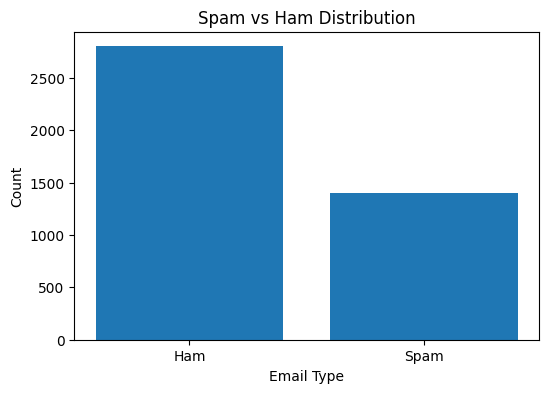

In [4]:
label_counts = df["Label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

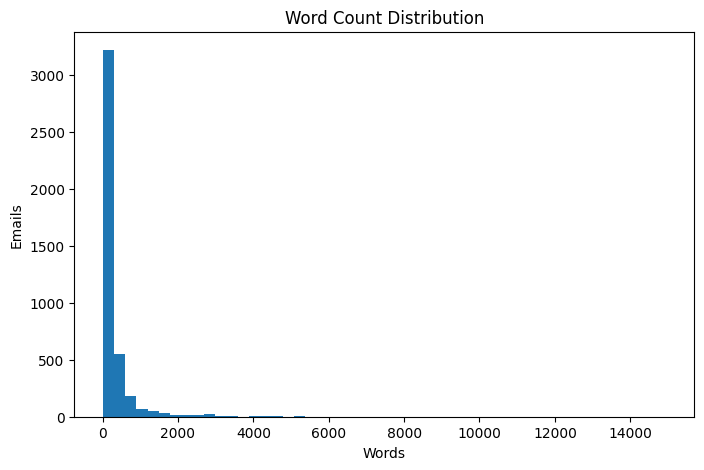

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["Word_Count"], bins=50)

plt.title("Word Count Distribution")

plt.xlabel("Words")

plt.ylabel("Emails")

plt.show()

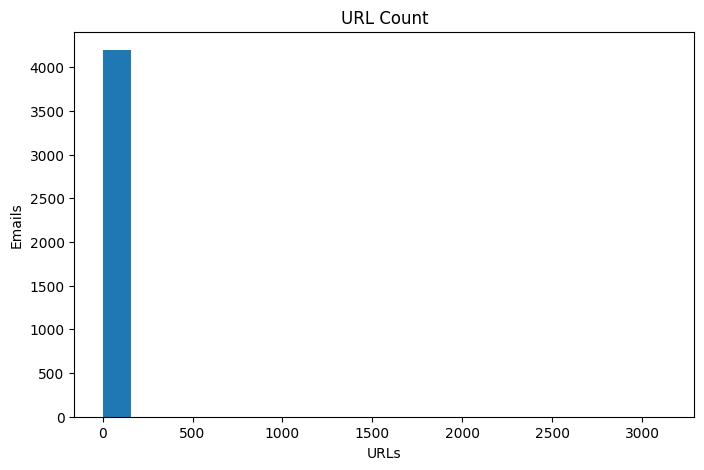

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["URL_Count"], bins=20)

plt.title("URL Count")

plt.xlabel("URLs")

plt.ylabel("Emails")

plt.show()

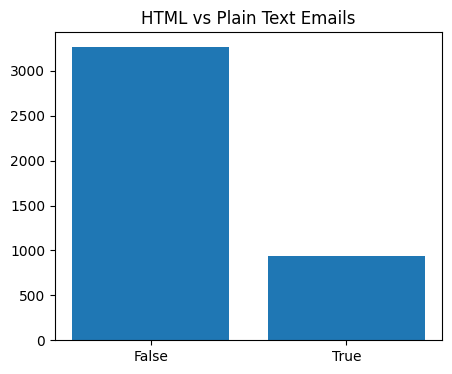

In [7]:
html_counts = df["Is_HTML"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(
    html_counts.index.astype(str),
    html_counts.values
)

plt.title("HTML vs Plain Text Emails")

plt.show()


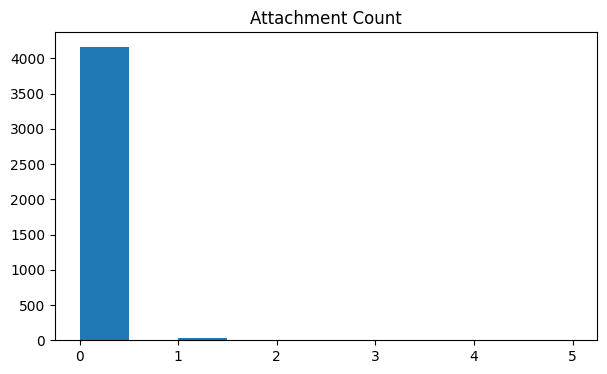

In [8]:
plt.figure(figsize=(7,4))

plt.hist(df["Attachment_Count"], bins=10)

plt.title("Attachment Count")

plt.show()

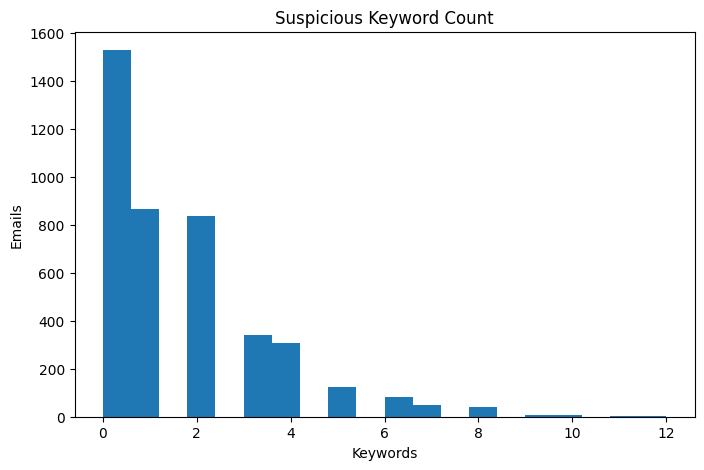

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Suspicious_Keyword_Count"], bins=20)

plt.title("Suspicious Keyword Count")

plt.xlabel("Keywords")

plt.ylabel("Emails")

plt.show()

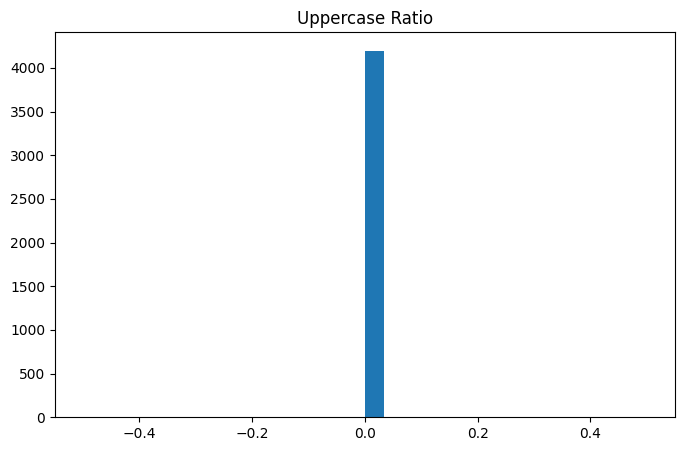

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["Uppercase_Ratio"], bins=30)

plt.title("Uppercase Ratio")

plt.show()

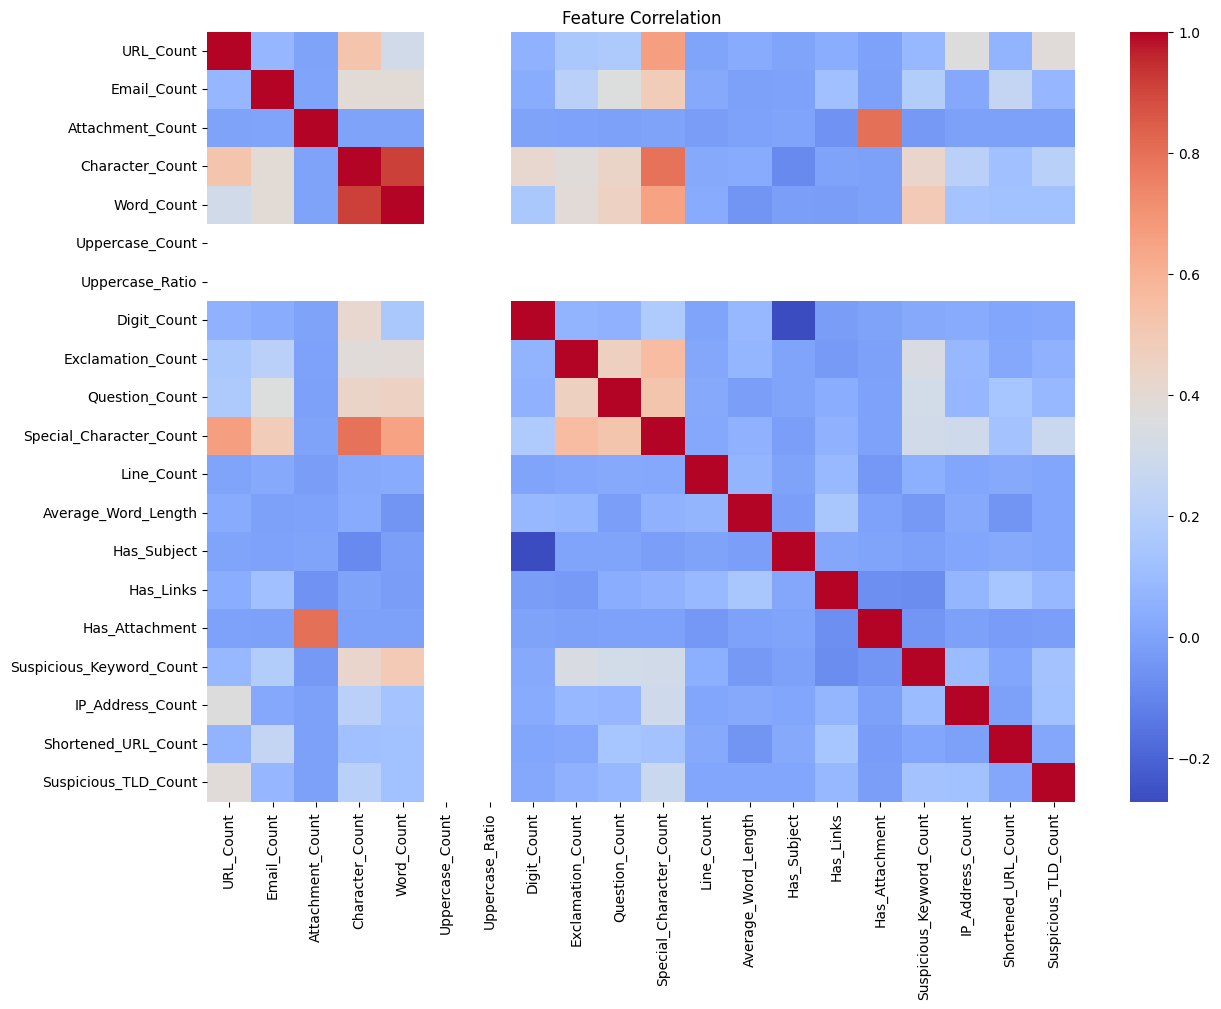

In [12]:
import seaborn as sns

numeric = df.select_dtypes(include="number")

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation")

plt.show()